# Model B
## PCuAC-only vs PCuAC+NirK

**Question**: Can PCuAC sequence-derived features predict whether a PCuAC-containing bacterial species also contains NirK?

**Notebook structure**
Data inspection -> Statistical exploration -> Feature relationships -> Model building -> Model interpretation

**Goal**: Understand which sequence-derived PCuAC features differ between `pcuac_only` and `both` species. Then, understand whether these differences are strong and consistent enough to be predictive.

### Dataset design
- Unit of analysis: one bacterial species = one row
- Target:
    Using binary classification
    `0` = `pcuac_only` species has PCuAC but not NirK
    `1` = `both` species has PCuAC and NirK
- Features:
    PCuAC sequence-derived physicochemical features only
    Length
    Molecular weight (MW)
    Isoelectric point (pI)
    GRAVY
    Aromaticity
    20 amino-acid composition fractions
- Notes:
    `species`, `taxid`, `organism_name`, and accessions are taxonomy information only retained for reporting and not used as model inputs

### Notebook parameters and where

| Configuration | Section |
|---|---|
| `RANDOM_STATE`, `TEST_SIZE`, `CORR_THRESHOLD`, `CV_FOLDS`, `INPUT_PATH` | Section X.X |
| Logistic Regression `class_weight`, `max_depth`, `min_samples_leaf`, ... | Section X.X |

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


# Data Loading & Inspection

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, export_text, export_graphviz
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)
from IPython.display import Image, display
import joblib

# Background for plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Remove sklearn warnings not relevant to model comparison
warnings.filterwarnings("ignore", message=".*was fitted without feature names.*")

print("Imports completed successfully.")

Imports completed successfully.


In [15]:
# File paths
INPUT_PATH = "final_feature_table.csv" # Save final feature table to the same destination as this notebook
OUTPUT_DIR = "results" # Figures, Tables, Models will be saved under these folders

# Parameters
RANDOM_STATE = 11 # Seed set for reproducibility of results in report
TEST_SIZE = 0.20 # Held-out test set proportion > Train/Test split of 80/20
CORR_THRESHOLD = 0.90 # If |r| > this threshold = one feature dropped
CV_FOLDS = 5 # Stratified CV folds used for tuning
ALPHA = 0.05 # Signifiance threshold for statistical testing 

# Feature names
AA_LETTERS = "ACDEFGHIKLMNPQRSTVWY"
BASE_PCUAC_FEATURES = [
    "pcuac_length", "pcuac_molecular_weight", "pcuac_isoelectric_point", 
    "pcuac_gravy", "pcuac_aromaticity",
]
AA_PCUAC_FEATURES = [f"pcuac_aa_frac_{aa}" for aa in AA_LETTERS]
ALL_PCUAC_FEATURES = BASE_PCUAC_FEATURES + AA_PCUAC_FEATURES

METADATA_COLUMNS =[
    "species", "taxid", "organism_name", "nirK_rep_accession",
    "pcuac_rep_accession", "species_resolved", "nirK_present","pcuac_presnt",
]

# Output folders
for output in ("figures", "tables", "models"):
    os.makedirs(os.path.join(OUTPUT_DIR, output), exist_ok=True)

# Confirmation of features count
print(f"PCuAC features available: {len(ALL_PCUAC_FEATURES)}")

# Class colors preset
GROUP_COLORS = {
    "pcuac_only": "#FCD0DA",
    "both": "#645E08"
}


PCuAC features available: 25


### Helper Functions


In [5]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Returns evaluations of standard classification metrics for a fitted model.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    baseline = max(y_test.mean(), 1 - y_test.mean())
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "naive_baseline_accuracy": baseline,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }

In [41]:
def plot_model_evaluation(models_and_data: dict, y_test, suptitle=None, savepath_prefix=None):
    """
    Plot ROC and precision-recall (PR) curves for 1 >= fitted models
    evaluated on held-out test data.

    For a single model = generate a confusion matrix.
    For multiple models = only the ROC and PR curves are plotted.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, (model, X_te) in models_and_data.items():
        RocCurveDisplay.from_estimator(model, X_te, y_test, name=name, ax=axes[0])
        PrecisionRecallDisplay.from_estimator(model, X_te, y_test, name=name, ax=axes[1])
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axes[0].set_title("ROC curve " + (f"{suptitle}" if suptitle else ""))
    axes[1].set_title("Precision-Recall curve " + (f"{suptitle}" if suptitle else ""))
    fig.tight_layout()
    if savepath_prefix:
        fig.savefig(f"{savepath_prefix}_roc_pr.png", dpi=200, bbox_inches="tight")
    plt.show()

    if len(models_and_data) == 1:
        name, (model, X_te) = next(iter(models_and_data.items()))
        fig2, ax2 = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay.from_estimator(
            model, X_te, y_test, display_labels=["pcuac_only", "both"],
            cmap="PuBu", colorbar=False, ax=ax2,
        )
        ax2.set_title(f"Confusion matrix for {name} model")
        fig2.tight_layout()
        if savepath_prefix:
            fig2.savefig(f"{savepath_prefix}_confusion.png", dpi=200, bbox_inches="tight")
        plt.show()


In [7]:
def get_permutation_importance(model, X_test, y_test, feature_names, n_repeats=30):
    result = permutation_importance(
        model, X_test, y_test, scoring="f1",
        n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=-1,
    )
    return pd.DataFrame({
        "feature": feature_names,
        "mean_importance": result.importances_mean,
        "std_importance": result.importances_std,
    }).sort_values("mean_importance", ascending=False).reset_index(drop=True)

In [8]:
def plot_importance_bar(importance_df, value_col, title, savepath=None, top_n=15, color="#43B157"):
    top = importance_df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, max(4, 0.3 * len(top))))
    xerr = top["std_importance"] if "std_importance" in top.columns else None
    ax.barh(top["feature"], top[value_col], xerr=xerr, color=color)
    ax.set_xlabel(value_col)
    ax.set_title(title)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

### Load Dataset

In [9]:
df_raw = pd.read_csv(INPUT_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head())
print(f"The full final dataset contains {df_raw.shape[0]} species. \nThis the total number of species rows consisting of, \npcuac_only (n=3637) + nirK only (n=1717) + both (461).")

Shape: (5815, 59)


,species,taxid,organism_name,nirK_present,pcuac_present,class,nirK_rep_accession,pcuac_rep_accession,species_resolved,nirK_length,...,pcuac_aa_frac_M,pcuac_aa_frac_N,pcuac_aa_frac_P,pcuac_aa_frac_Q,pcuac_aa_frac_R,pcuac_aa_frac_S,pcuac_aa_frac_T,pcuac_aa_frac_V,pcuac_aa_frac_W,pcuac_aa_frac_Y
0,neisseria meningitidis,1053687;1069614;1069618;1095666;1095672;109569...,Neisseria meningitidis,1,1,both,WP_002258661.1,WP_002212839.1,1,392.0,...,0.07006,0.02548,0.03185,0.03185,0.02548,0.03822,0.03822,0.10191,0.00637,0.00637
1,cutibacterium acnes,1031709;1182749;1292038;1302634;1302635;130263...,Cutibacterium acnes,1,0,nirK_only,WP_002512805.1,NaN,1,314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cutibacterium modestum,1182753;1182754;1912223;2559073;765109;765123;...,Cutibacterium modestum 31N;Cutibacterium modestum,1,0,nirK_only,WP_002529289.1,NaN,1,314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[propionibacterium] namnetense,1051006;1574624,[Propionibacterium] namnetense SK182B-JCVI;Cut...,1,0,nirK_only,WP_002550210.1,NaN,1,314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,simonsiella muelleri,641147;72;72,Simonsiella muelleri,1,1,both,WP_002642011.1,WP_002641845.1,1,387.0,...,0.03030,0.06061,0.04545,0.03030,0.02273,0.04545,0.10606,0.12121,0.00000,0.01515


The full final dataset contains 5815 species. 
This the total number of species rows consisting of, 
pcuac_only (n=3637) + nirK only (n=1717) + both (461).


### Inspect Dataset

In [10]:
n_species = len(df_raw)
n_features = len(ALL_PCUAC_FEATURES)

print(f"Number of species (rows): {n_species}")
print(f"Number of PCuAC feature columns: {n_features}")
print(f"Total columns in file: {df_raw.shape[1]}")
print("\n")
print("Data types:")
print(df_raw.dtypes.value_counts())


Number of species (rows): 5815
Number of PCuAC feature columns: 25
Total columns in file: 59


Data types:
float64    50
object      6
int64       3
Name: count, dtype: int64


## Missing Values & Duplicates

In [11]:
eda_df = df_raw[df_raw["class"].isin(["pcuac_only", "both"])].copy()

missing_summary = eda_df[ALL_PCUAC_FEATURES].isna().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary):
    display(missing_summary)
else:
    print("No missing values in pcuac features (pcuac_only/both rows).")

n_duplicate_rows = eda_df.duplicated(subset=ALL_PCUAC_FEATURES).sum()
print(f"\nFully duplicated PCuAC feature rows: {n_duplicate_rows}")

# Check by species ID separatley from features duplication (see Chapter 4 discussion: homology)
if "species" in eda_df.columns:
    n_duplicate_species = eda_df["species"].duplicated().sum()
    print(f"Duplicate species identifiers: {n_duplicate_species}")


No missing values in pcuac features (pcuac_only/both rows).

Fully duplicated PCuAC feature rows: 37
Duplicate species identifiers: 0


### Class balance

class
pcuac_only    3637
nirK_only     1717
both           461
Name: count, dtype: int64

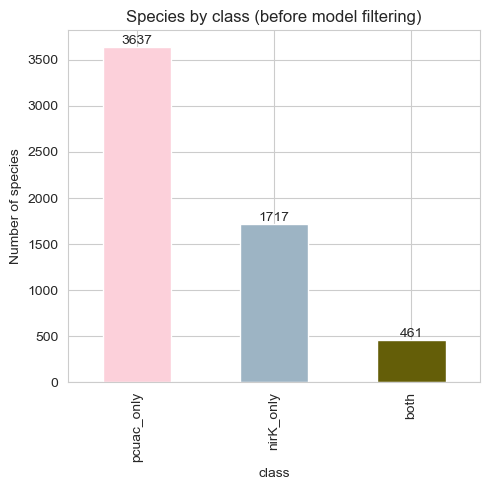

Model B subset (pcuac_only + both):
class
pcuac_only    3637
both           461
Name: count, dtype: int64
Class imbalance ratio: 7.89 :1


In [14]:
class_counts = df_raw["class"].value_counts()
display(class_counts)

fig, ax = plt.subplots(figsize=(5,5))
class_counts.plot(kind="bar", ax = ax, color=["#FCD0DA", "#9DB4C4", "#645E08"])
ax.set_ylabel("Number of species")
ax.set_title("Species by class (before model filtering)")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + max(class_counts.values) * 0.01, str(v), ha="center")
fig.tight_layout()
plt.show()

model_b_counts = eda_df["class"].value_counts()

print("Model B subset (pcuac_only + both):")
print(model_b_counts)
print(f"Class imbalance ratio: {model_b_counts.max()/model_b_counts.min():.2f} :1")


### Feature distributions
`nirK_only` species are not part of Model B and are excluded from here onward.

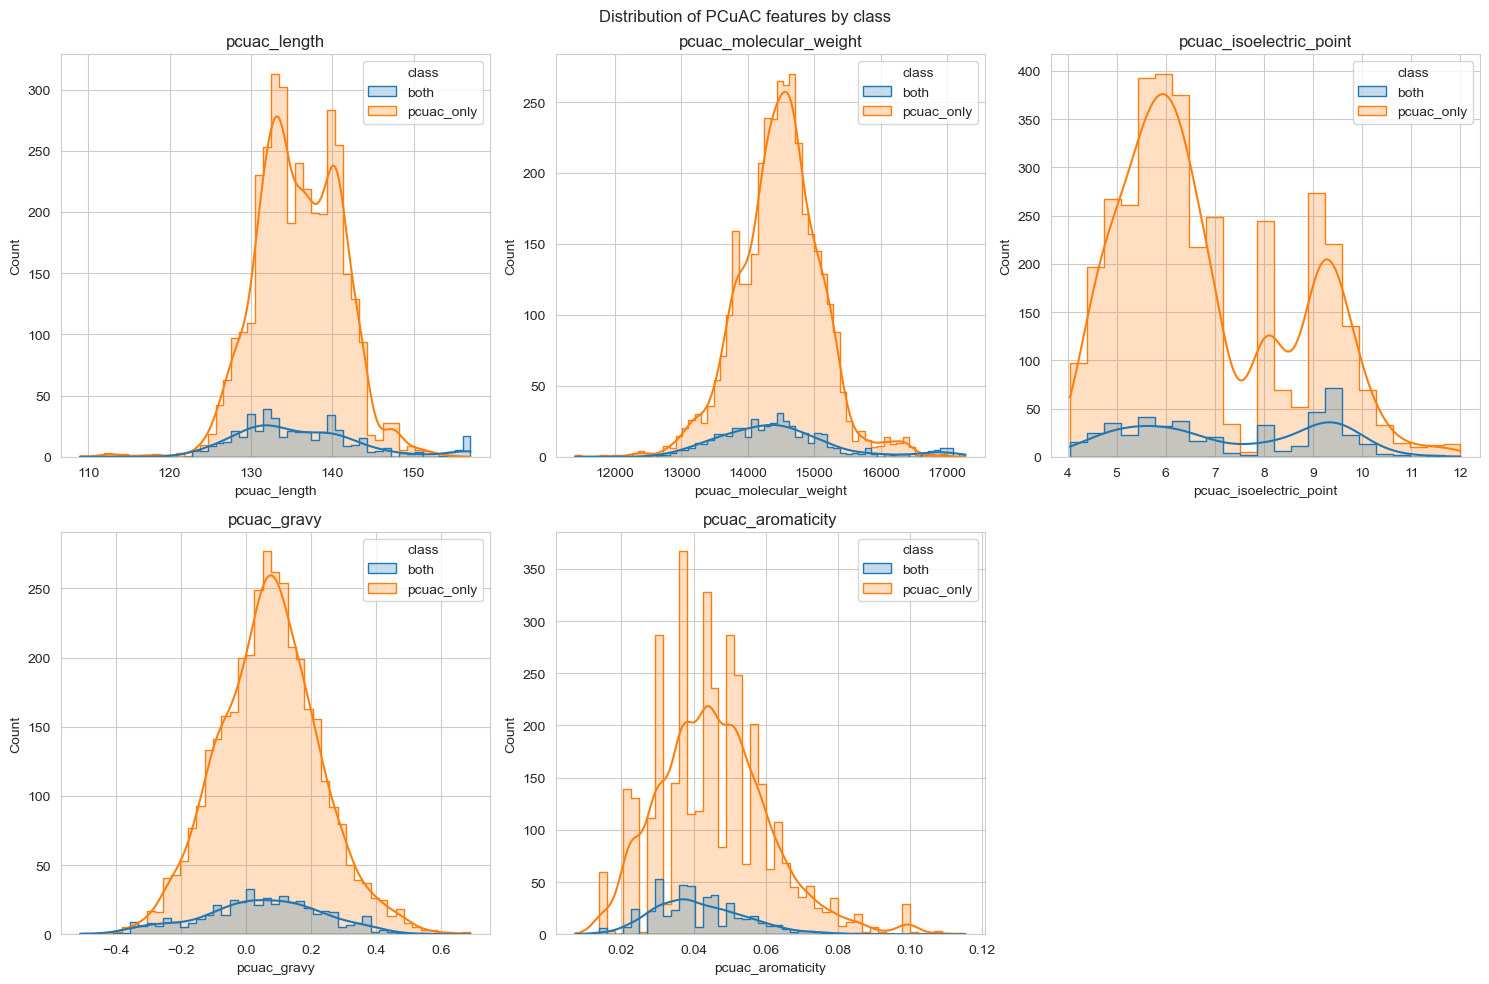

In [16]:
# Distribution of Model B PCuAC specific features by class
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax, feat in zip(axes.flat, BASE_PCUAC_FEATURES):
    sns.histplot(data=eda_df, x=feat, hue="class", kde=True, element="step", ax=ax)
    ax.set_title(feat)
axes.flat[-1].axis("off")
fig.suptitle("Distribution of PCuAC features by class")
fig.tight_layout()
plt.show()


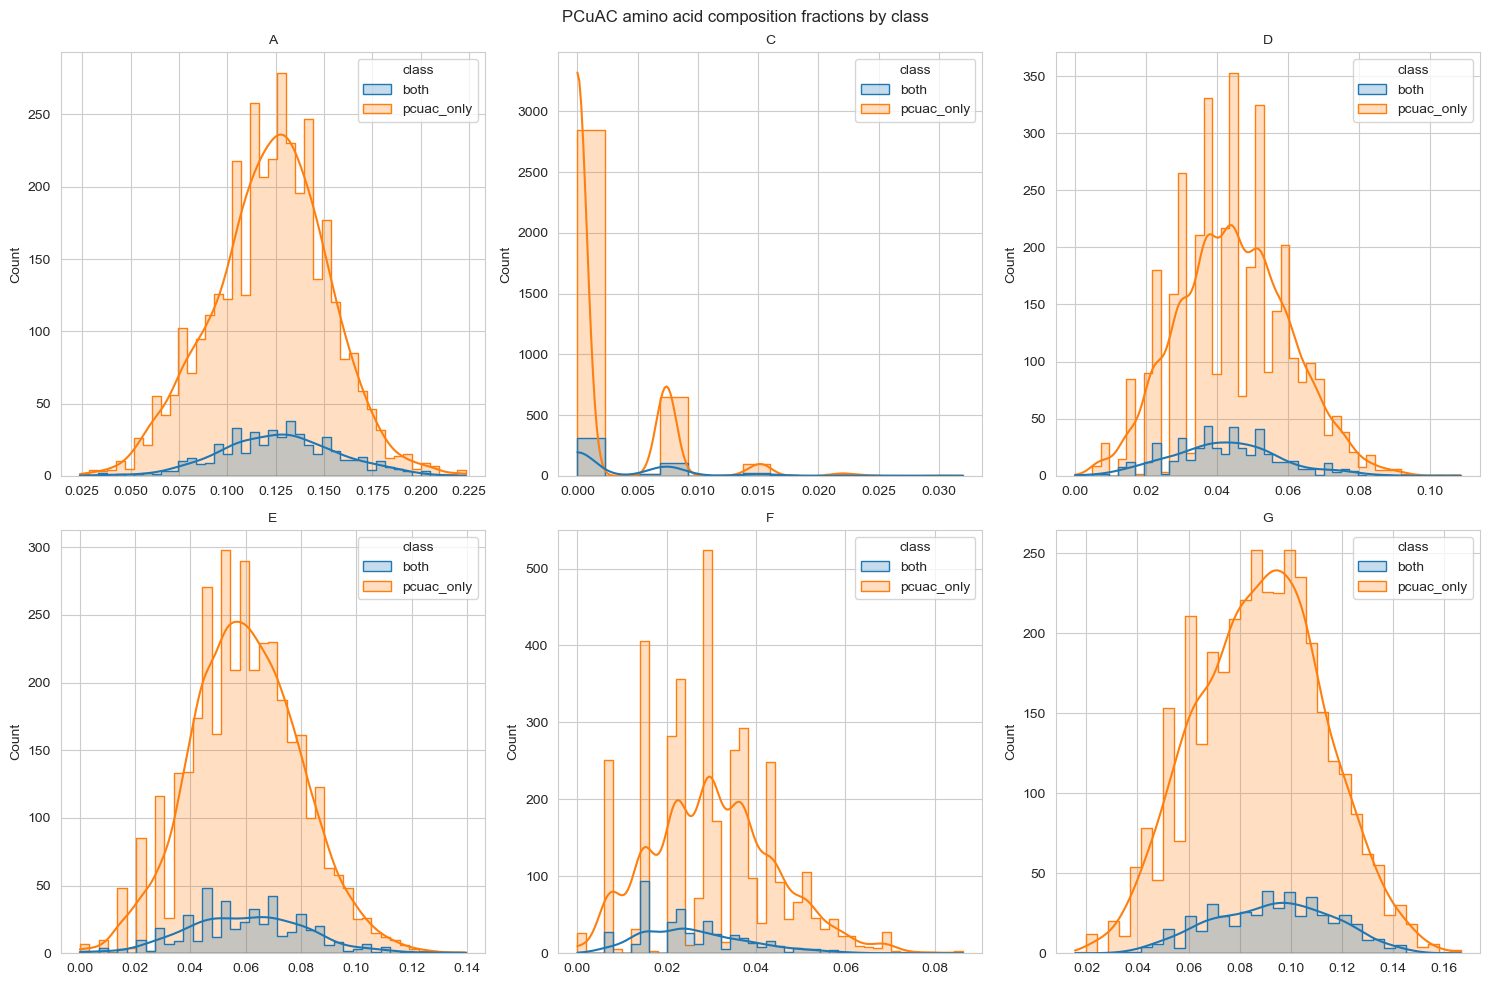

In [17]:
# Distribution of PCuAC amino acid composition fractions by class
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax, feat in zip(axes.flat, AA_PCUAC_FEATURES):
    sns.histplot(data=eda_df, x=feat, hue="class", kde=True, element="step", ax=ax)
    ax.set_title(feat.replace("pcuac_aa_frac_",""), fontsize=10)
    ax.set_xlabel("")
fig.suptitle("PCuAC amino acid composition fractions by class")
fig.tight_layout()
plt.show()


### Boxplots

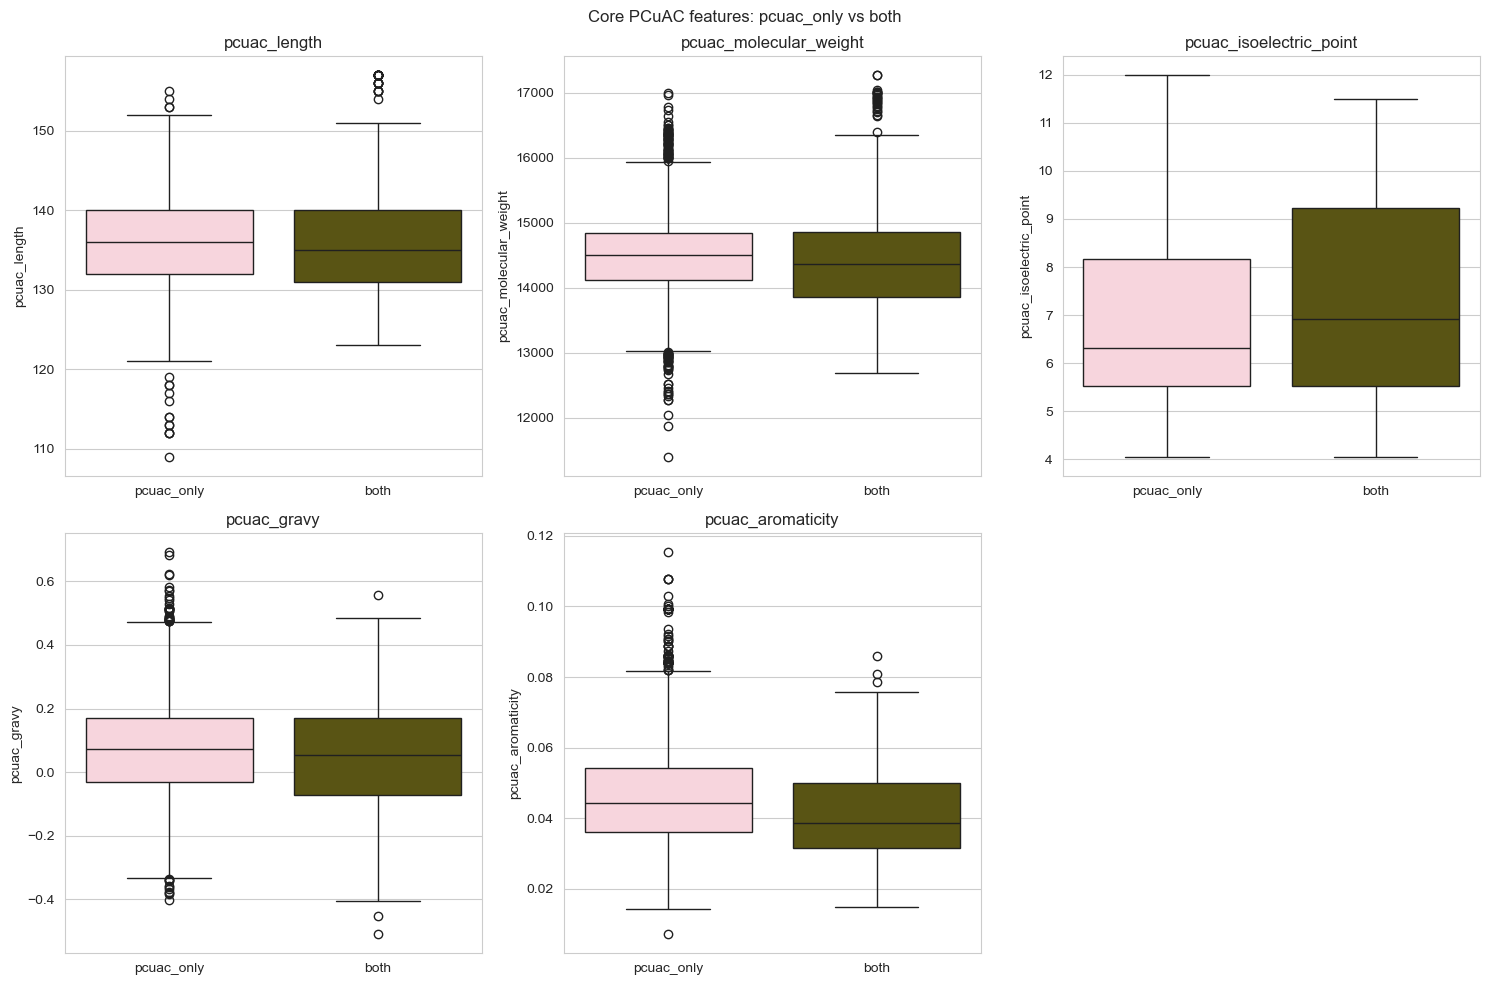

In [18]:
# Boxplots comparing pcuac_only vs both
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax, feat in zip(axes.flat, BASE_PCUAC_FEATURES):
    sns.boxplot(data=eda_df, x="class", y=feat, hue="class",
                ax=ax, order=["pcuac_only", "both"], 
                palette=GROUP_COLORS,
                legend=False)
    ax.set_title(feat)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Core PCuAC features: pcuac_only vs both")
fig.tight_layout()
plt.show()

# Save to outputs folder
fig.savefig(os.path.join(OUTPUT_DIR, "figures", "eda_boxplots_model_B.png"), dpi=200, bbox_inches="tight")


## Statistical Analysis


Feature by feature question on whether the feature actually differs between pcuac_only and both species.

The statistical testing offers insight as to whether a feature differs between groups but **does not** answer whether the feature can predict class membership.


### Mann-Whitney U tests with effect size

In [19]:
def rank_biserial(u_stat, n1, n2):
    """
    Calculate rank bi-serial effect size from a Mann-Whitney U statistic.
    """
    return 1 - (2 * u_stat) / (n1 * n2)

In [20]:
def effect_size_label(r):
    r = abs(r)
    if r < 0.1:
        return "negligible"
    elif r < 0.3:
        return "small"
    elif r < 0.5:
        return "medium"
    else:
        return "large"

In [21]:
# Define groups
group_pcuac_only = eda_df.loc[eda_df["class"] == "pcuac_only", ALL_PCUAC_FEATURES]
group_both = eda_df.loc[eda_df["class"] == "both", ALL_PCUAC_FEATURES]

stat_rows = []
for feat in ALL_PCUAC_FEATURES:
    x, y = group_pcuac_only[feat].dropna(), group_both[feat].dropna()
    u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
    effect_size = rank_biserial(u_stat, len(x), len(y))
    direction = "higher in both" if y.median () > x.median() else "higher in pcuac_only"
    stat_rows.append({
        "feature": feat,
        "median_pcuac_only": x.median(),
        "median_both": y.median(),
        "p_value": p_val,
        "effect_size_r": effect_size,
        "effect_size_label": effect_size_label(effect_size),
        "direction": direction,
    })

    stats_df = pd.DataFrame(stat_rows)


In [22]:
# Benjamini-Hochberg correction for multiple testing
reject, p_adj, _, _ = multipletests(stats_df["p_value"], alpha=ALPHA, method ="fdr_bh")
stats_df["p_adj"] = p_adj
stats_df["significant"] = reject

stats_df = stats_df.sort_values("p_adj").reset_index(drop=True)
stats_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "statistical_test_results.csv"), index=False)

display(stats_df)
print(f"\n{stats_df['significant'].sum()} / {len(stats_df)}"
      f"Features significant at BH-adjusted alpha = {ALPHA}")

,feature,median_pcuac_only,median_both,p_value,effect_size_r,effect_size_label,direction,p_adj,significant
0,pcuac_aa_frac_W,0.00709,0.00735,1.670026e-16,0.230339,small,higher in both,4.175064e-15,True
1,pcuac_aa_frac_I,0.04167,0.03150,3.168626e-15,-0.225059,small,higher in pcuac_only,3.960783e-14,True
2,pcuac_aa_frac_F,0.02985,0.02400,2.153977e-10,-0.181259,small,higher in pcuac_only,1.794981e-09,True
3,pcuac_aa_frac_C,0.00000,0.00000,1.517639e-08,0.119360,small,higher in pcuac_only,9.485242e-08,True
4,pcuac_aromaticity,0.04444,0.03876,1.732549e-07,-0.149176,small,higher in pcuac_only,8.662743e-07,True
5,pcuac_aa_frac_N,0.02143,0.01538,1.559540e-05,-0.123316,small,higher in pcuac_only,6.498082e-05,True
6,pcuac_aa_frac_R,0.03226,0.03597,3.165959e-05,0.118783,small,higher in both,9.329676e-05,True
7,pcuac_aa_frac_Y,0.00758,0.00752,3.358683e-05,-0.118168,small,higher in pcuac_only,9.329676e-05,True
8,pcuac_isoelectric_point,6.30500,6.91200,2.630929e-05,0.119990,small,higher in both,9.329676e-05,True
9,pcuac_aa_frac_G,0.08889,0.09353,5.940362e-05,0.114618,small,higher in both,1.485090e-04,True



18 / 25Features significant at BH-adjusted alpha = 0.05


### Visualise significant features

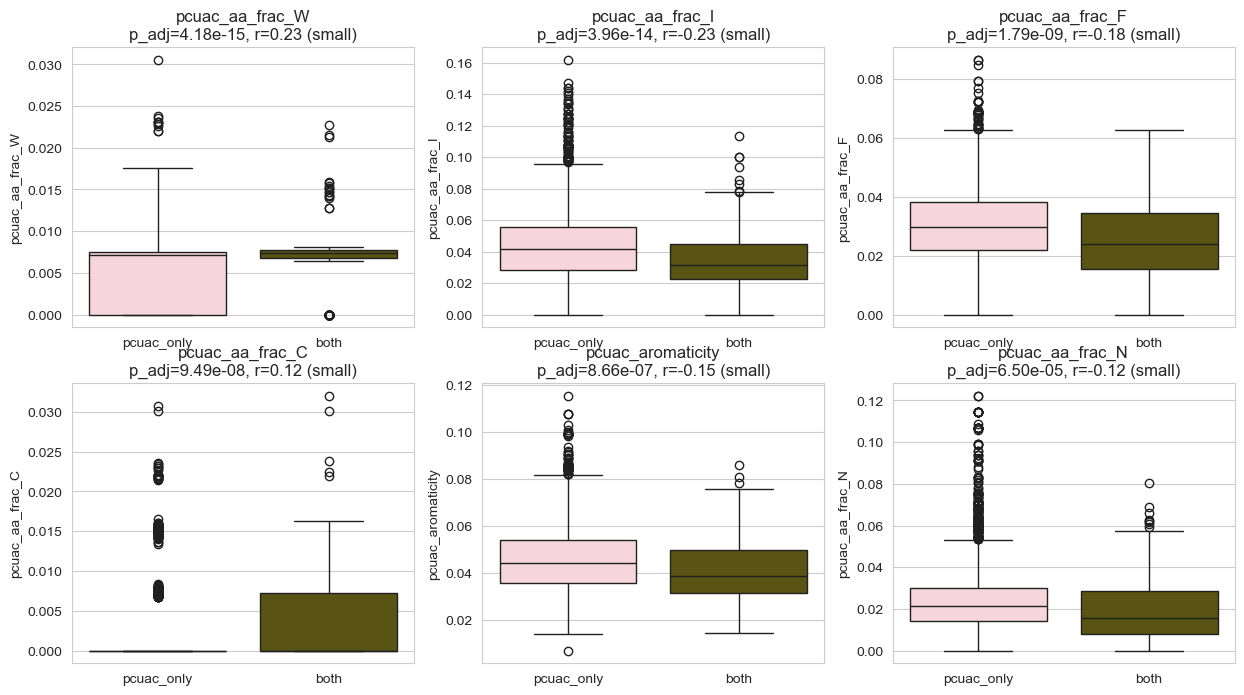

In [23]:
significant_features = stats_df[stats_df["significant"]].head(6)["feature"].tolist()

if significant_features:
    n_cols = 3
    n_rows = int(np.ceil(len(significant_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, feat in zip(axes, significant_features):
        sns.boxplot(data=eda_df, x="class", y=feat,hue="class",
                    ax=ax, order=["pcuac_only", "both"],
                    palette=GROUP_COLORS)
        row = stats_df.loc[stats_df["feature"] == feat].iloc[0]
        ax.set_title(f"{feat}\np_adj={row.p_adj:.2e}, r={row.effect_size_r:.2f} ({row.effect_size_label})")
        ax.set_xlabel("")
        for ax in axes [len(significant_features):]:
            ax.axis("off")
            fig.suptitle("Significant PCuAC features after BH correction", y=1.02)
            fig.tight_layout()
            fig.savefig(os.path.join(OUTPUT_DIR, "figures", "significant_features_boxplots.png"), dpi=200, bbox_inches="tight")
            plt.show()
else:
    print("No features determined significant after BH correction.")


## Feature relationships and preprocessing
Examining which features are redundant with each other and how each model type needs its features prepared *before* model fitting

### Correlation matrix

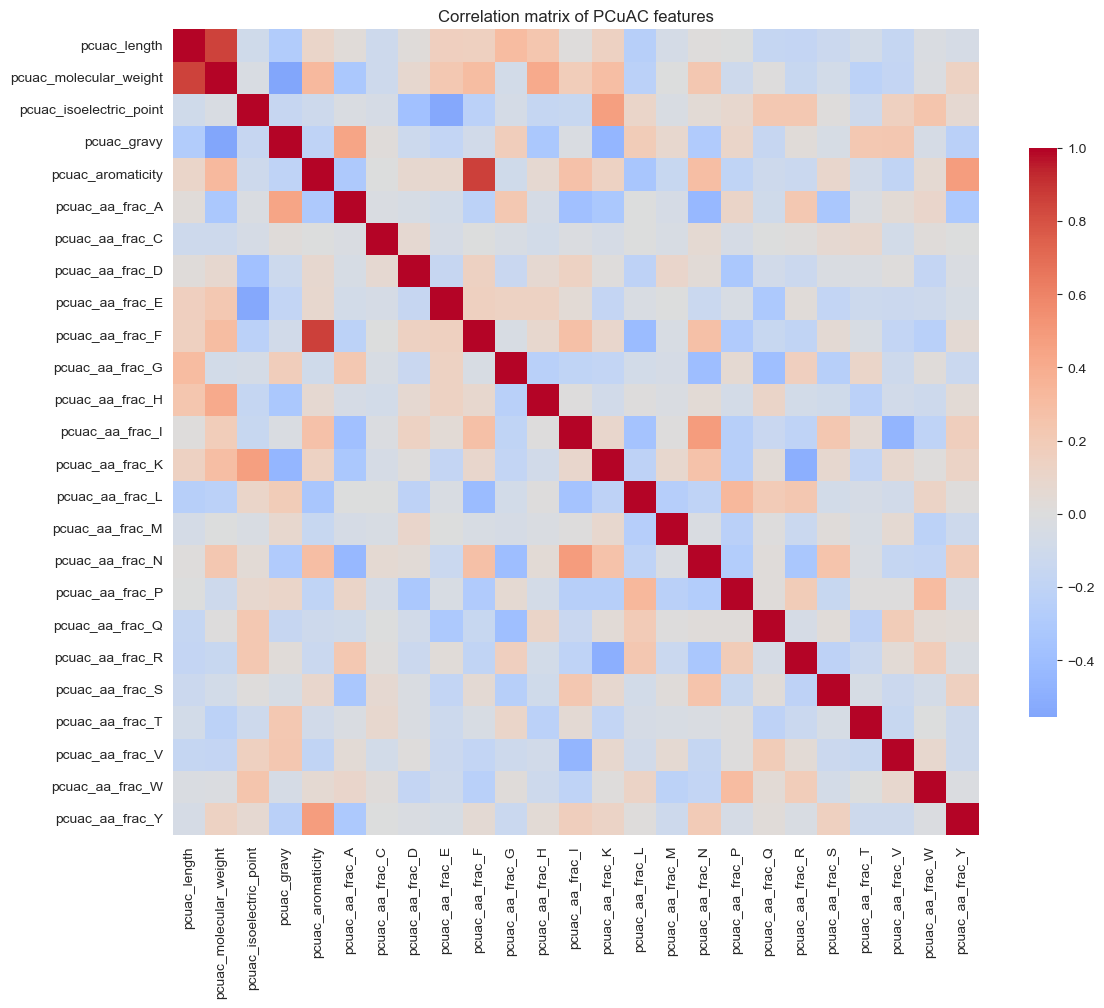

In [24]:
corr_matrix = eda_df[ALL_PCUAC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink":0.7})
ax.set_title("Correlation matrix of PCuAC features")
fig.tight_layout()
plt.show()


### Identifying highly correlated features

In [25]:
corr_abs = corr_matrix.abs().to_numpy().copy()
np.fill_diagonal(corr_abs, 0.0)
corr_abs = pd.DataFrame(corr_abs, index=corr_matrix.index, columns=corr_matrix.columns)
high_corr_pairs = (
    corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] > CORR_THRESHOLD].sort_values(
    "abs_correlation", ascending=False
)

display(high_corr_pairs)

,feature_1,feature_2,abs_correlation


### Scaling for modelling notes
Model-specific feature preparation  

Different models require different preprocessing.   

**Logistic Regression:** Features are standardised using StandardScaler because the L2 regularisation penalty is affected by feature magnitude. Without scaling, features with larger numerical ranges could be penalised differently from smaller-scale features.

**Random Forest:** Features are not scaled because tree-based splits depend on the ordering of values rather than their absolute scale. Rescaling therefore does not change the resulting splits or predictions. Keeping the original units also makes tree-based interpretation easier.

The correlation analysis shown above is descriptive, using the full pcuac_only + both dataset. However, the correlation-based feature filter and StandardScaler used for modelling are fitted after the train/test split and on the training set only. This prevents information from the test set influencing feature selection or scaling and avoids data leakage.


# Train/Test Split

In [26]:
df_model = df_raw[df_raw["class"].isin(["pcuac_only","both"])].copy()
df_model["target"] = (df_model["class"] == "both").astype(int)

X = df_model[ALL_PCUAC_FEATURES].reset_index(drop=True)
y = df_model["target"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} species. {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test: {len(X_test)} species. {y_test.value_counts(normalize=True).round(3).to_dict()}")



Train: 3278 species. {0: 0.887, 1: 0.113}
Test: 820 species. {0: 0.888, 1: 0.112}


In [27]:
# Apply training-set correlation filter
def correlation_filter(X_train, features, threshold=CORR_THRESHOLD):
    """
    Remove highly correlated features using X_train only.
    For each highly correlated pair, remove the feature with the higher
    mean absolute (|r|) correlation with the remaining features.
    """
    remaining = list(features)
    dropped_rows= []
    while True:
        corr = X_train[remaining].corr().abs().copy()
        corr_vals = corr.values.copy()
        np.fill_diagonal(corr_vals, 0.0)
        corr = pd.DataFrame(corr_vals, index=corr.index, columns=corr.columns)
        max_corr = corr.values.max()
        if max_corr <= threshold or len(remaining) <= 1:
            break
        i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
        feat_i, feat_j = remaining[i], remaining[j]
        mean_i, mean_j = corr[feat_i].mean(), corr[feat_j].mean()
        drop_feat = feat_i if mean_i >= mean_j else feat_j
        keep_feat = feat_j if drop_feat == feat_i else feat_i
        dropped_rows.append({
            "dropped_feature": drop_feat, "correlated_with": keep_feat,
            "abs_correlation": round(float(max_corr), 4),
        })
        remaining.remove(drop_feat)
    return remaining, pd.DataFrame(dropped_rows)

selected_features, dropped_corr_df = correlation_filter(X_train, ALL_PCUAC_FEATURES)

print(f"Kept {len(selected_features)}/{len(ALL_PCUAC_FEATURES)} features"
      f"after |r| > {CORR_THRESHOLD} filter.")
if len(dropped_corr_df):
    display(dropped_corr_df)

dropped_corr_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "correlation_dropped_features.csv"), index=False)

X_train = X_train[selected_features]
X_test = X_test[selected_features]


Kept 25/25 featuresafter |r| > 0.9 filter.


In [28]:
# Apply scaling (fit on training set only)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=selected_features, index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=selected_features, index=X_test.index
)

print("Scaler was fit on the training set only. Then applied to both train and test.")
print(f"\n{len(selected_features)} features carried forward into modelling: {selected_features}")

Scaler was fit on the training set only. Then applied to both train and test.

25 features carried forward into modelling: ['pcuac_length', 'pcuac_molecular_weight', 'pcuac_isoelectric_point', 'pcuac_gravy', 'pcuac_aromaticity', 'pcuac_aa_frac_A', 'pcuac_aa_frac_C', 'pcuac_aa_frac_D', 'pcuac_aa_frac_E', 'pcuac_aa_frac_F', 'pcuac_aa_frac_G', 'pcuac_aa_frac_H', 'pcuac_aa_frac_I', 'pcuac_aa_frac_K', 'pcuac_aa_frac_L', 'pcuac_aa_frac_M', 'pcuac_aa_frac_N', 'pcuac_aa_frac_P', 'pcuac_aa_frac_Q', 'pcuac_aa_frac_R', 'pcuac_aa_frac_S', 'pcuac_aa_frac_T', 'pcuac_aa_frac_V', 'pcuac_aa_frac_W', 'pcuac_aa_frac_Y']


# Machine Learning Models
Model 1: **Logistic Regression (LR)**   
models the probability of belonging to the `both` class as a weighted combinatoin of the (standardized) features, passed throuhg the logistic function:

P(both) = sigmoid( b0 + b1·x1 + b2·x2 + ... )

equivalently:   
log( P(both) / P(pcuac_only) ) = b0 + b1·x1 + ...

----

**Regularisation**

 *C vs lambda.* scikit-learn parameterises L2 regularisation strength as `C = 1 / lambda`:
- **Smaller C** -> **larger lambda** -> **stronger regularisation** -> coefficients shrunk further toward zero -> simpler, a more conservative model.
- **Larger C** -> **smaller lambda** -> **weaker regularisation** -> coefficients allowed to grow larger -> fits training data more closely, more prone to overfitting at this sample size.

**class_weight:** `"balanced"` reweights the loss so the minority class (`both`) counts more, given the imbalance shown earlier.




In [29]:
# Adjustable: Logistic Regression hyperparameters
class_weight = "balanced" # "balanced" or None
solver = "lbfgs" # "lbfgs" (L2 only) or "liblinear" (L2 or L1)
penalty = "l2" # "l2" (either solver) or "l1" (liblinear only)

## C selected via cross-validation

In [30]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

lr_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
        ("logistic_regression",
         LogisticRegression(class_weight=class_weight, solver=solver, penalty=penalty,max_iter=5000,
                            random_state=RANDOM_STATE))]),
    param_grid={"logistic_regression__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="f1", cv=cv, n_jobs=-1,)

lr_grid.fit(X_train, y_train)

C = lr_grid.best_params_["logistic_regression__C"]

print("C selected by 5-fold CV:", C, "\nCV F1 =", round(lr_grid.best_score_, 4))

C selected by 5-fold CV: 0.1 
CV F1 = 0.2766


## Fit and evaluate

In [31]:
log_reg = LogisticRegression(
    C=C, class_weight=class_weight, solver=solver, penalty=penalty,
    max_iter=5000, random_state=RANDOM_STATE,
)
log_reg.fit(X_train_scaled,y_train)

lr_metrics = evaluate_model(log_reg, X_test_scaled, y_test, "logistic_regression")
pd.DataFrame([lr_metrics])


,model,accuracy,naive_baseline_accuracy,precision,recall,f1,f1_macro,roc_auc,pr_auc
0,logistic_regression,0.618293,0.887805,0.170149,0.619565,0.266979,0.504471,0.666209,0.172162


In [32]:
print(classification_report(y_test, log_reg.predict(X_test_scaled), target_names=["pcuac_only", "both"]))



              precision    recall  f1-score   support

  pcuac_only       0.93      0.62      0.74       728
        both       0.17      0.62      0.27        92

    accuracy                           0.62       820
   macro avg       0.55      0.62      0.50       820
weighted avg       0.84      0.62      0.69       820



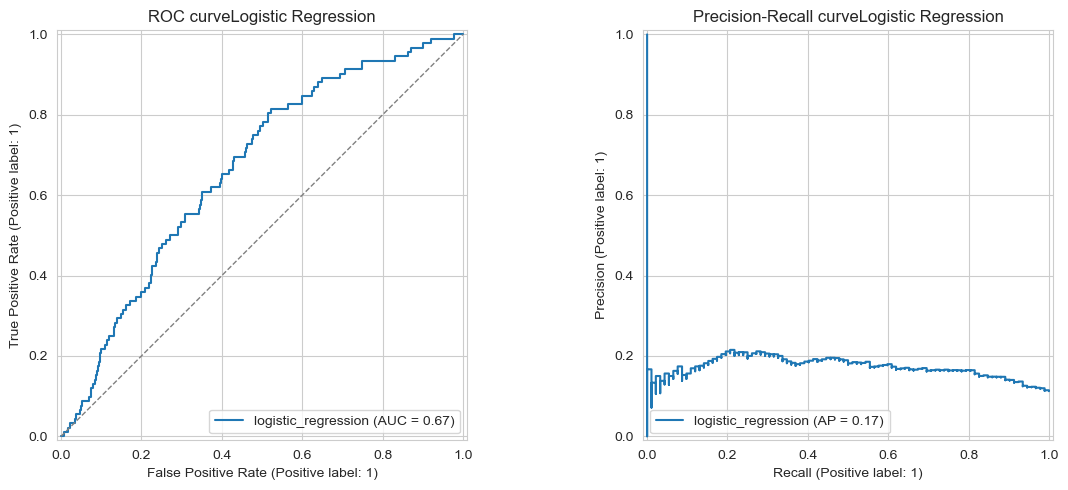

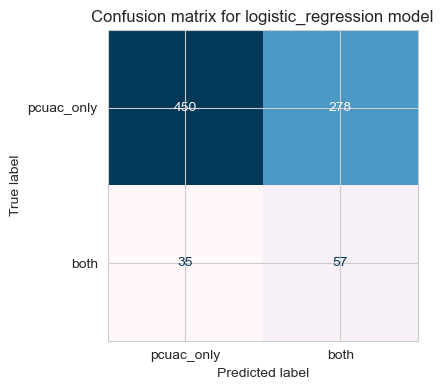

In [33]:
plot_model_evaluation(
    {"logistic_regression": (lr_grid.best_estimator_, X_test)}, y_test,
    suptitle="Logistic Regression",
    savepath_prefix=os.path.join(OUTPUT_DIR, "figures", "logreg"),
)

## Coefficients

,feature,standardized_coefficient
0,pcuac_aa_frac_I,-0.316699
1,pcuac_gravy,-0.239700
2,pcuac_aa_frac_C,0.238806
3,pcuac_isoelectric_point,0.208646
4,pcuac_aa_frac_H,-0.154325
5,pcuac_aa_frac_A,0.153779
6,pcuac_aa_frac_W,0.150976
7,pcuac_aa_frac_G,0.142784
8,pcuac_aa_frac_F,-0.123604
9,pcuac_aa_frac_E,0.116712


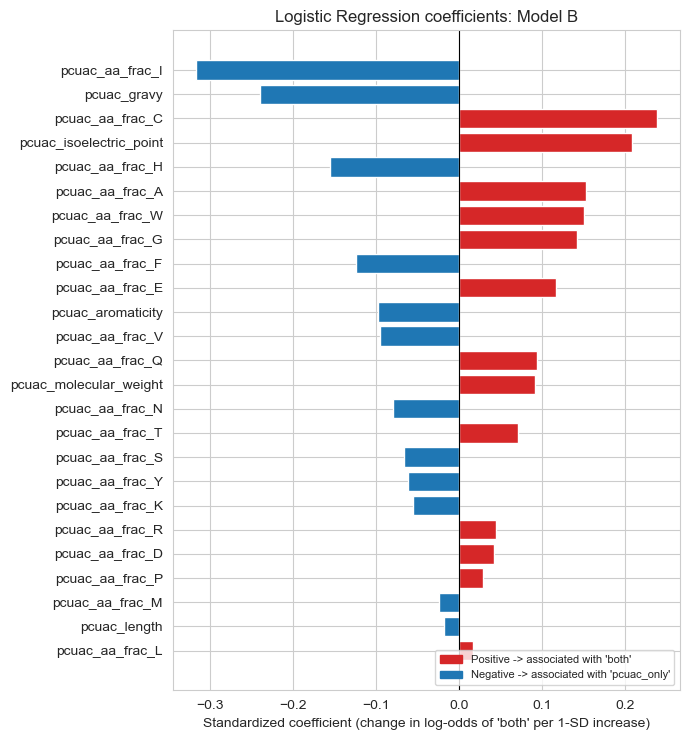

In [34]:
best_lr = lr_grid.best_estimator_
log_reg = best_lr.named_steps["logistic_regression"]

lr_coef_df = pd.DataFrame({
    "feature": selected_features,
    "standardized_coefficient": log_reg.coef_[0],
}).sort_values("standardized_coefficient", key=np.abs, ascending=False).reset_index(drop=True)

display(lr_coef_df)

fig, ax = plt.subplots(figsize=(7, max(4, 0.3 * len(lr_coef_df))))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in lr_coef_df["standardized_coefficient"]]
ax.barh(lr_coef_df["feature"], lr_coef_df["standardized_coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient (change in log-odds of 'both' per 1-SD increase)")
ax.set_title("Logistic Regression coefficients: Model B")
ax.invert_yaxis()
ax.legend(
    handles=[
        Patch(color="#d62728", label="Positive -> associated with 'both'"),
        Patch(color="#1f77b4", label="Negative -> associated with 'pcuac_only'"),
    ],
    loc="lower right", fontsize=8,
)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "figures", "logreg_coefficients.png"), dpi=200, bbox_inches="tight")
plt.show()

lr_coef_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "logistic_regression_coefficients.csv"), index=False)


**How to read this plot**
- **Positive coefficient (red)** -> higher values of that feature are associated with an *increased* probability of `both`.
- **Negative coefficient (blue)** -> higher values of that feature are associated with `pcuac_only`.
- **Magnitude** reflects the strength of the coefficient in standardized units, making coefficients comparable across features because the features were standardized before fitting.

**These coefficients represent predictive associations learned from this dataset, not biological causation.** A feature having a strong, consistent coefficient means the model found it statistically useful for separating the two classes here BUT it does not by itself establish a link to NirK co-occurrence.


In [38]:
# Biological Summary of isoelectric point (pI)
# isoelectric point, pcuac_only vs both
# IMPORTANT NOTE! the standardized coefficient plot tells you pI's direction
# and strength in the model (positive --> associated with 'both'),
# while this summary tells you the actual biological quantity behind that

# NOTE: pI is a whole-protein physicochemical property (not an amino-acid
# composition fraction), so the residue-count framing used for tryptophan in
# Model A doesn't apply here. This cell reports central tendency and spread
# of pI directly instead.

pi_summary = (
    eda_df.groupby("class")
    .agg(
        n_species=("pcuac_isoelectric_point", "size"),
        mean_pi=("pcuac_isoelectric_point", "mean"),
        median_pi=("pcuac_isoelectric_point", "median"),
        min_pi=("pcuac_isoelectric_point", "min"),
        max_pi=("pcuac_isoelectric_point", "max"),
    )
)

print("Isoelectric point (pI) in PCuAC: pcuac_only vs both\n")
for cls in ["pcuac_only", "both"]:
    row = pi_summary.loc[cls]
    print(f"{cls} (n={int(row.n_species)} species):")
    print(f"  Mean pI: {row.mean_pi:.2f} (median {row.median_pi:.2f}, "
          f"range {row.min_pi:.2f}-{row.max_pi:.2f})")

n_pi = pi_summary.loc["pcuac_only", "mean_pi"]
b_pi = pi_summary.loc["both", "mean_pi"]
direction = "lower" if n_pi > b_pi else "higher"

print(f"\nSummary: pcuac_only species have a {direction} average isoelectric point than "
      f"'both' species. \nMean pI {n_pi:.2f} vs {b_pi:.2f}.")

# Significance test for this feature calculated above
pi_stats = stats_df.loc[stats_df["feature"] == "pcuac_isoelectric_point"].iloc[0]
sig_label = "statistically significant" if pi_stats["significant"] else "not statistically significant"
print(f"\nThis difference is {sig_label} after multiple-testing correction "
      f"(BH-adjusted p = {pi_stats['p_adj']:.2e}, effect size = "
      f"{pi_stats['effect_size_label']} [r = {pi_stats['effect_size_r']:.2f}]).")

Isoelectric point (pI) in PCuAC: pcuac_only vs both

pcuac_only (n=3637 species):
  Mean pI: 6.83 (median 6.30, range 4.05-12.00)
both (n=461 species):
  Mean pI: 7.26 (median 6.91, range 4.05-11.49)

Summary: pcuac_only species have a higher average isoelectric point than 'both' species. 
Mean pI 6.83 vs 7.26.

This difference is statistically significant after multiple-testing correction (BH-adjusted p = 9.33e-05, effect size = small [r = 0.12]).


# Model 2: Random Forest
**Random Forest (RF)**  

Random Forest combines many decision trees, each trained on a bootstrap sample of the training species with a random subset of features considered at each split. For classification, the individual trees vote for a class, and the forest assigns the class receiving the most votes. Fit on the **unscaled** correlation-filtered features (`X_train`/`X_test`).
    Refer to ***Scaling for modelling notes*** for why scaling isn't needed here.


In [42]:
# Adjustable: Random Forest hyperparameters
n_estimators = 300
max_depth = None # None = trees grow until stopping criteria are met
min_samples_leaf = 3
class_weight = "balanced" # "balanced" or None

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
    class_weight=class_weight, random_state=RANDOM_STATE, n_jobs=-1,
)
rf_model.fit(X_train, y_train)

rf_metrics = evaluate_model(rf_model, X_test, y_test, "random_forest")
pd.DataFrame([rf_metrics])

,model,accuracy,naive_baseline_accuracy,precision,recall,f1,f1_macro,roc_auc,pr_auc
0,random_forest,0.903659,0.887805,0.76,0.206522,0.324786,0.636458,0.847587,0.537819


In [44]:
print(classification_report(y_test, rf_model.predict(X_test), target_names=["pcuac_only", "both"]))


              precision    recall  f1-score   support

  pcuac_only       0.91      0.99      0.95       728
        both       0.76      0.21      0.32        92

    accuracy                           0.90       820
   macro avg       0.83      0.60      0.64       820
weighted avg       0.89      0.90      0.88       820



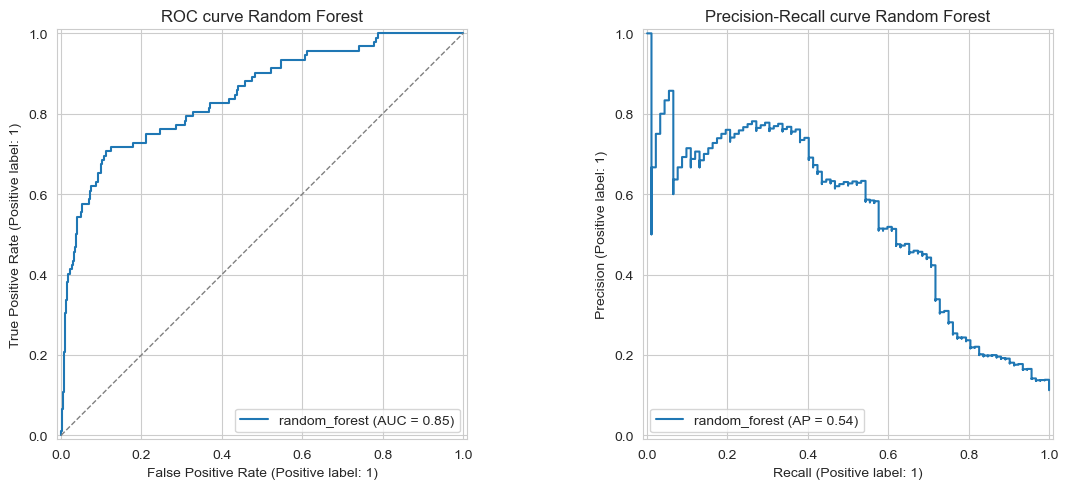

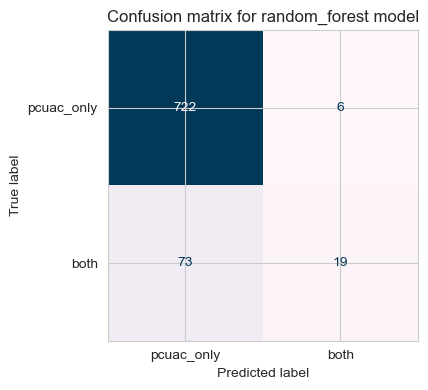

In [45]:
plot_model_evaluation(
    {"random_forest": (rf_model, X_test)}, y_test,
    suptitle="Random Forest",
    savepath_prefix=os.path.join(OUTPUT_DIR, "figures", "rf"),
)

## Feature importance

,feature,gini_importance
0,pcuac_aa_frac_I,0.056799
1,pcuac_aa_frac_W,0.052316
2,pcuac_aa_frac_F,0.049603
3,pcuac_molecular_weight,0.049160
4,pcuac_gravy,0.048283
5,pcuac_isoelectric_point,0.045967
6,pcuac_aromaticity,0.043199
7,pcuac_aa_frac_R,0.042577
8,pcuac_aa_frac_M,0.040566
9,pcuac_aa_frac_H,0.039359


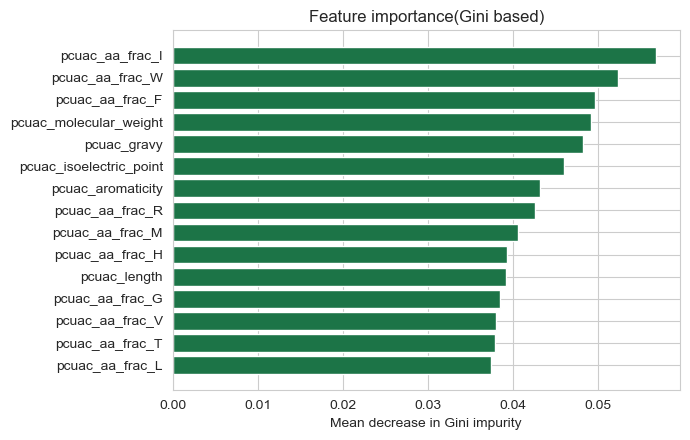

In [46]:
rf_importance_df = pd.DataFrame({
    "feature": selected_features,
    "gini_importance": rf_model.feature_importances_,
}).sort_values("gini_importance", ascending=False).reset_index(drop=True)
display(rf_importance_df)

fig, ax = plt.subplots(figsize=(7, max(4, 0.3 * len(rf_importance_df.head(15)))))
top = rf_importance_df.head(15).iloc[::-1]
ax.barh(top["feature"], top["gini_importance"], color="#1C7447")
ax.set_xlabel("Mean decrease in Gini impurity")
ax.set_title("Feature importance(Gini based)")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "figures", "rf_gini_importance.png"), dpi=200, bbox_inches="tight")
plt.show()

rf_importance_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "rf_gini_importance.csv"), index=False)


## Permutation importance
**Permutation importance asks:** *"What happens to the model's performance if it randomly shuffles this feature across the test species?"*

A **higher value** = that the model was relying more on that feature when making its predictions.

This does **not** = that the feature causes NirK presence. It only shows that the feature was useful to the model for distinguishing between the two classes.


,feature,mean_importance,std_importance
0,pcuac_length,0.166598,0.030540
1,pcuac_aa_frac_F,0.138421,0.034776
2,pcuac_aa_frac_W,0.133440,0.020806
3,pcuac_molecular_weight,0.111701,0.020892
4,pcuac_isoelectric_point,0.106561,0.022771
5,pcuac_aa_frac_M,0.093082,0.026214
6,pcuac_aa_frac_R,0.087293,0.021053
7,pcuac_aa_frac_P,0.081798,0.022275
8,pcuac_aa_frac_H,0.081691,0.019759
9,pcuac_aa_frac_Q,0.078339,0.023184


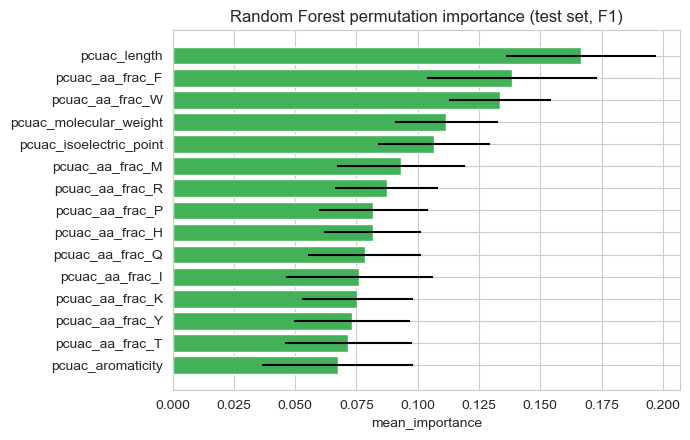

In [47]:
rf_perm_df = get_permutation_importance(rf_model, X_test, y_test, selected_features)
display(rf_perm_df)
plot_importance_bar(
    rf_perm_df, "mean_importance",
    "Random Forest permutation importance (test set, F1)",
    savepath=os.path.join(OUTPUT_DIR, "figures", "rf_permutation_importance.png"),
)
rf_perm_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "rf_permutation_importance.csv"), index=False)

# Compare models
Logsitic Regression vs Random Forest

In [48]:
quick_compare = pd.DataFrame([lr_metrics, rf_metrics]).set_index("model")[
    ["f1", "roc_auc", "pr_auc"]
]
display(quick_compare)

,f1,roc_auc,pr_auc
model,,,
logistic_regression,0.266979,0.666209,0.172162
random_forest,0.324786,0.847587,0.537819


## Repeated cross-validation
Repeated cross-validation:  
Stratified 5-fold CV, repeated 10 times, using the training set only. This checks how stable model performance is across different train/validation splits rather than tuning hyperparameters. Feature filtering and scaling are refit within each fold, so the held-out test set and the feature filtering and scaling perfrmed befoer modelling are not used.

In [49]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold

    def fit(self, X, y=None):
        remaining = list(X.columns)
        while True:
            corr = X[remaining].corr().abs()
            corr_vals = corr.values.copy()
            np.fill_diagonal(corr_vals, 0.0)
            corr = pd.DataFrame(corr_vals, index=corr.index, columns=corr.columns)
            max_corr = corr.values.max()
            if max_corr <= self.threshold or len(remaining) <= 1:
                break
            i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
            feat_i, feat_j = remaining[i], remaining[j]
            mean_i, mean_j = corr[feat_i].mean(), corr[feat_j].mean()
            drop_feat = feat_i if mean_i >= mean_j else feat_j
            remaining.remove(drop_feat)
        self.selected_features_ = remaining
        return self

    def transform(self, X):
        return X[self.selected_features_]

In [50]:
X_train_full = X.loc[X_train.index]
y_train_full = y.loc[y_train.index]

lr_pipeline = Pipeline([
    ("corr_filter", CorrelationFilter(threshold=CORR_THRESHOLD)),
    ("scaler", StandardScaler()),
    ("clf", clone(log_reg)),
])

rf_pipeline = Pipeline([
    ("corr_filter", CorrelationFilter(threshold=CORR_THRESHOLD)),
    ("clf", clone(rf_model)),
])

In [51]:
cv_scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

cv_rows = []
for name, pipe in [
    ("logistic_regression", lr_pipeline),
    ("random_forest", rf_pipeline),
]:
    scores = cross_validate(pipe, X_train_full, y_train_full, cv=rcv, scoring=cv_scoring, n_jobs=-1)
    row = {"model": name}
    for metric in cv_scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_summary_df = pd.DataFrame(cv_rows).set_index("model")

print("Repeated cross-validation summary")
print("")
display(cv_summary_df)
cv_summary_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "cv_repeated_summary.csv"))


Repeated cross-validation summary



,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,,,,,,,
logistic_regression,0.274864,0.024391,0.174565,0.015393,0.647142,0.064080,0.675936,0.031049,0.189671,0.025434
random_forest,0.309988,0.055499,0.757043,0.082827,0.196201,0.041055,0.805811,0.025806,0.451885,0.049167


# Visualising model comparisons

In [52]:
comparison_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index("model")
display(comparison_df[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]])
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "tables", "metrics_comparison.csv"))

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
logistic_regression,0.618293,0.170149,0.619565,0.266979,0.666209,0.172162
random_forest,0.903659,0.760000,0.206522,0.324786,0.847587,0.537819


In [53]:
full_comparison = comparison_df[["f1", "precision", "recall", "roc_auc", "pr_auc"]].join(cv_summary_df)

print("Held-out test vs repeated CV")
print("")
display(full_comparison)
full_comparison.to_csv(os.path.join(OUTPUT_DIR, "tables", "test_vs_cv_comparison.csv"))

Held-out test vs repeated CV



,f1,precision,recall,roc_auc,pr_auc,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,,,,,,,,,,,,
logistic_regression,0.266979,0.170149,0.619565,0.666209,0.172162,0.274864,0.024391,0.174565,0.015393,0.647142,0.064080,0.675936,0.031049,0.189671,0.025434
random_forest,0.324786,0.760000,0.206522,0.847587,0.537819,0.309988,0.055499,0.757043,0.082827,0.196201,0.041055,0.805811,0.025806,0.451885,0.049167


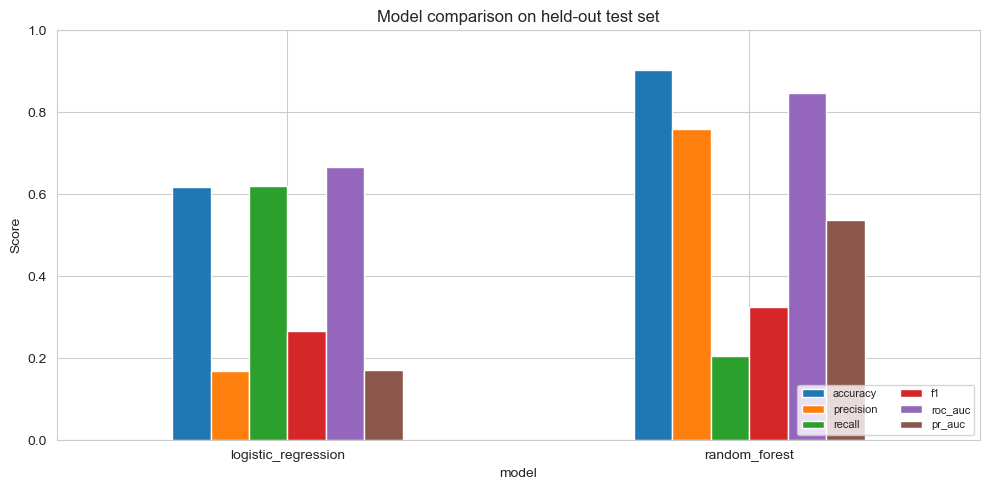

In [54]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model comparison on held-out test set")
ax.legend(loc="lower right", ncol=2, fontsize=8)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "figures", "model_comparison_bar.png"), dpi=200, bbox_inches="tight")
plt.show()

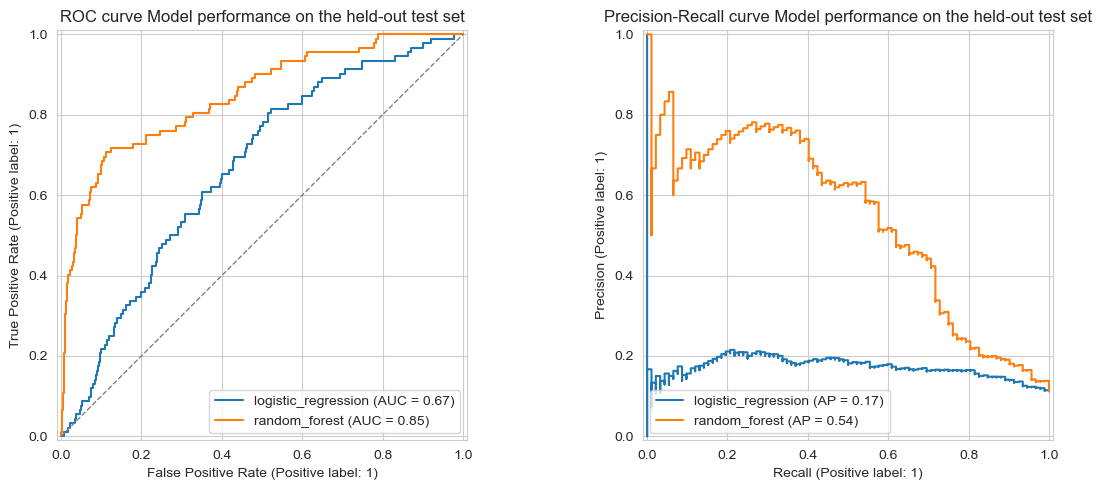

In [55]:
plot_model_evaluation(
    {
        "logistic_regression": (log_reg, X_test_scaled),
        "random_forest": (rf_model, X_test),
    },
    y_test, suptitle="Model performance on the held-out test set",
    savepath_prefix=os.path.join(OUTPUT_DIR, "figures", "comparison"),
)

# Biological interpretation
The results were interpreted using three complementary sources of evidence:

1. **Statistical testing:** features that differed between groups based on BH-adjusted significance and effect size.
2. **Logistic Regression:** features associated with the `both` class, based on the direction and magnitude of standardised coefficients.
3. **Random Forest:** features that contributed to predictive performance based on permutation importance.

Features that showed consistent evidence across these approaches were considered stronger candidates for biological interpretation, as they were supported by different analytical methods rather than a single model.

In [56]:
combined_rank = (
    stats_df[["feature", "p_adj", "effect_size_r", "significant"]]
    .merge(
        lr_coef_df.assign(
            lr_rank=lambda d: d["standardized_coefficient"].abs().rank(ascending=False)
        )[["feature", "lr_rank"]],
        on="feature",
    )
    .merge(
        rf_perm_df.assign(
            rf_rank=lambda d: d["mean_importance"].rank(ascending=False)
        )[["feature", "rf_rank"]],
        on="feature",
    )
    .assign(
        mean_model_rank=lambda d: d[["lr_rank", "rf_rank"]].mean(axis=1)
    )
    .sort_values("mean_model_rank")
    .reset_index(drop=True)
)

In [57]:
display(
    combined_rank.style
    .format({
        "p_adj": "{:.3g}",
        "effect_size_r": "{:.2f}",
        "lr_rank": "{:.0f}",
        "rf_rank": "{:.0f}",
        "mean_model_rank": "{:.1f}"
    })
    .background_gradient(
        subset=["mean_model_rank"],
        cmap="Blues_r"
    )
    .set_caption("Combined feature ranking")
)

,feature,p_adj,effect_size_r,significant,lr_rank,rf_rank,mean_model_rank
0,pcuac_isoelectric_point,9.33e-05,0.12,True,4,5,4.5
1,pcuac_aa_frac_W,4.18e-15,0.23,True,7,3,5.0
2,pcuac_aa_frac_F,1.79e-09,-0.18,True,9,2,5.5
3,pcuac_aa_frac_I,3.96e-14,-0.23,True,1,11,6.0
4,pcuac_aa_frac_H,0.00858,-0.08,True,5,9,7.0
5,pcuac_molecular_weight,0.000969,-0.10,True,14,4,9.0
6,pcuac_aa_frac_Q,0.237,0.04,False,13,10,11.5
7,pcuac_gravy,0.0308,-0.07,True,2,21,11.5
8,pcuac_aa_frac_C,9.49e-08,0.12,True,3,20,11.5
9,pcuac_aa_frac_G,0.000149,0.11,True,8,16,12.0


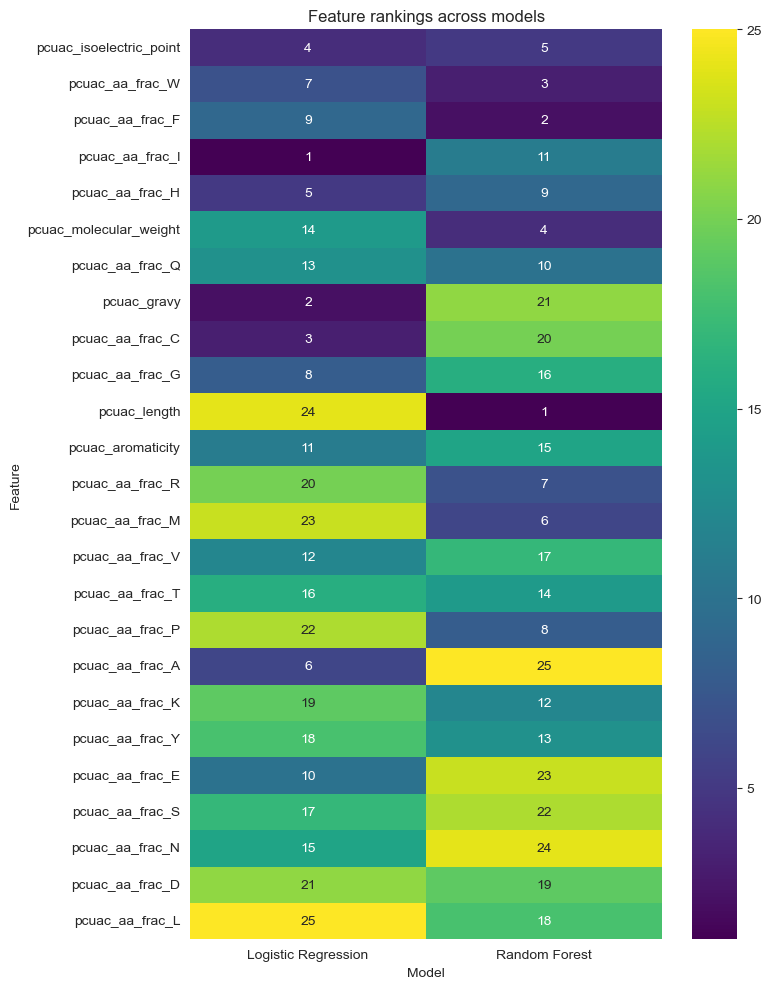

In [58]:
rank_plot = combined_rank.set_index("feature")[
    ["lr_rank", "rf_rank"]
].rename(columns={
    "lr_rank": "Logistic Regression",
    "rf_rank": "Random Forest"
})

plt.figure(figsize=(8, 10))

sns.heatmap(
    rank_plot,
    annot=True,
    cmap="viridis",
    fmt=".0f"
)

plt.title("Feature rankings across models")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save outputs

In [59]:
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "models", "scaler.joblib"))
joblib.dump(log_reg, os.path.join(OUTPUT_DIR, "models", "logistic_regression.joblib"))
joblib.dump(rf_model, os.path.join(OUTPUT_DIR, "models", "random_forest.joblib"))

print("Models saved to:", os.path.join(OUTPUT_DIR, "models"))
print("Tables saved to:", os.path.join(OUTPUT_DIR, "tables"))
print("Figures saved to:", os.path.join(OUTPUT_DIR, "figures"))
print("\nAll outputs from this run are saved under:", os.path.abspath(OUTPUT_DIR))

Models saved to: results/models
Tables saved to: results/tables
Figures saved to: results/figures

All outputs from this run are saved under: /Users/dayanara/Desktop/Dissertation/predicting-nirk-pcuac-cooccurrence-1/scripts/stage_5/results
